# RL

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG
import utils


data_rl_2 = {
    'timestep': [],
    'dxdt' : [],
    'delE':[]
}
runs = 10
rl_activs = []
experiment_name = "sac_cn10cb100_df"
experiment_folder = os.path.join("experiments",experiment_name)
best_model_folder = os.path.join(experiment_folder, "model" )
best_model_path = os.path.join(best_model_folder, "best_model.zip")

if 'ppo' in experiment_name:
    loaded_model = PPO.load(best_model_path)
elif 'sac' in experiment_name:
    loaded_model = SAC.load(best_model_path)
elif 'ddpg' in experiment_name:
    loaded_model = DDPG.load(best_model_path)


weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

for i in range(runs):
    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)
    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol
    flow_rates= []
    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0
    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        if i == (6/del_t):
            T = 38
        elif i >= (8/del_t):
            T = T_opt

        temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))


        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated

        MuX = MuX * temp_dep

        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate

        # if i > (2/del_t) and i < (4/del_t):
        #     pass
        # else:
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                flow_rates.append(substrate_action)
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration
            else:
                flow_rates.append(0)
        else:
            flow_rates.append(0)
        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        data_rl_2["timestep"].append(i)
        data_rl_2['dxdt'].append(dXdt)
        data_rl_2['delE'].append(delE)

        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
        
    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]
    S_C_R = (S/X)
    rl_activs.append(E[-1])

print(list(rl_activs))

[np.float64(2.779023285537937), np.float64(2.590626617959323), np.float64(2.9450347414850597), np.float64(3.210721948745054), np.float64(3.0423606190684027), np.float64(3.00703949106987), np.float64(2.510297648515026), np.float64(2.723672021498586), np.float64(2.881440620709776), np.float64(2.6354813979680745)]


# TC

In [38]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import numpy as np


weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)



tc_e_activities = []
tc_scr = []
runs = 10

for i in range(runs):
    start_flow_volume = 0.0008892908583470567
    feed_interval = 0.15295954782159268
    ramp_factor = 0.05983974644980618
    initial_volume = start_flow_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor
    # Initial conditions
    X0 = 0.7  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max =  config.MU_MAX  # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME
    substrate_actions = []
    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        if i == (6/del_t):
            T = 38
        elif i >= (8/del_t):
            T = T_opt

        temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))

        MuX = utils.cell_growth_rate(S)

        MuX = MuX * temp_dep
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX

        # Find change in substrate
        delS = dSdt * del_t

        # if i > (6/del_t) and i < (8/del_t):
        #     pass
        # else:
        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                substrate_actions.append(substrate_action)
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration


        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
        
    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]
    S_C_R = (S/X)
    tc_e_activities.append(E[-1])


# '''
# ================================================================================================================================================
#                                                     Plotting      
# ================================================================================================================================================
# '''

# fig, ax1 = plt.subplots()
# ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")
# fig.suptitle(f"Max Enzyme Activity: {max(E)}")
# ax2 = ax1.twinx()
# ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

# ax3 = ax1.twinx()
# ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
# #ax3.spines['right'].set_position(('outward',60))
# ax3.spines['right'].set_position(('axes',1.15))

# ax1.set_ylabel("Enzyme Activity U/L", color="red")
# ax1.set_xlabel("Time (hours)")
# ax2.set_ylabel("Substrate mol/L ", color="orange")
# ax3.set_ylabel("Cells CDW g/L", color="blue")

# ax1.tick_params(axis='y',colors="red")
# ax2.tick_params(axis='y',colors="orange")
# ax3.tick_params(axis='y',colors="blue")

# ax2.spines['right'].set_color("orange")
# ax3.spines['right'].set_color("blue")
# ax3.spines['left'].set_color("red")
# #fig.legend()
# plt.show()

# plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
# plt.axhline(y=config.OPT_SUB_CELL_RATIO)
# plt.xlabel("Time H")
# plt.ylabel("Substrate to cell ratio (mol/g)")
# plt.legend()

print(tc_e_activities)


[np.float64(2.371213430468931), np.float64(2.371213430468931), np.float64(2.371213430468931), np.float64(2.371213430468931), np.float64(2.371213430468931), np.float64(2.371213430468931), np.float64(2.371213430468931), np.float64(2.371213430468931), np.float64(2.371213430468931), np.float64(2.371213430468931)]


# Plot for stop the pump perturbation

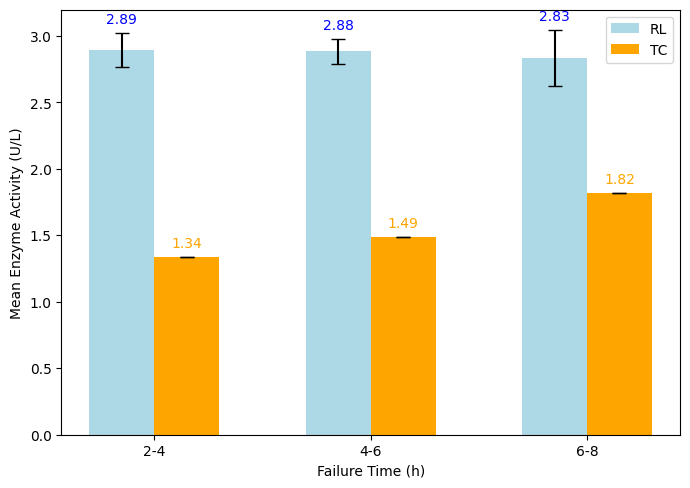

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Example enzyme activity data for both methods
RL_data = {
    '2-4': [np.float64(2.9425773597422618), np.float64(3.002225246368232), np.float64(2.980830020133836), np.float64(2.915529991819996), np.float64(2.996475824319206), np.float64(2.6782808983304998), np.float64(2.603831874148016), np.float64(2.9361830393178283), np.float64(2.9204581360945285), np.float64(2.954265729002064)]
,
    '4-6': [np.float64(2.9179298970053957), np.float64(2.9234892333497524), np.float64(2.7397272058056967), np.float64(2.778180908510377), np.float64(2.8519046512426645), np.float64(3.053929945915819), np.float64(2.855430372600662), np.float64(2.8085005031497983), np.float64(3.0299604820118042), np.float64(2.862194026338624)]

,
    '6-8': [np.float64(2.779023285537937), np.float64(2.590626617959323), np.float64(2.9450347414850597), np.float64(3.210721948745054), np.float64(3.0423606190684027), np.float64(3.00703949106987), np.float64(2.510297648515026), np.float64(2.723672021498586), np.float64(2.881440620709776), np.float64(2.6354813979680745)]


}

Traditional_data = {
    '2-4': [1.3372345880652345] * 10,
    '4-6': [1.485399703130431] * 10,
    '6-8': [1.8182676764322576] * 10
}

# Categories
categories = ['2-4', '4-6', '6-8']

# Calculate means and standard deviations for each category
means_rl = [np.mean(RL_data[cat]) for cat in categories]
std_rl = [np.std(RL_data[cat]) for cat in categories]

means_trad = [np.mean(Traditional_data[cat]) for cat in categories]
std_trad = [np.std(Traditional_data[cat]) for cat in categories]

# Bar width and x positions
bar_width = 0.30
x = np.arange(len(categories))

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Plot bars with error bars
bars_rl = ax.bar(x - bar_width/2, means_rl, bar_width, yerr=std_rl, label='RL', color='lightblue', capsize=5)
bars_trad = ax.bar(x + bar_width/2, means_trad, bar_width, yerr=std_trad, label='TC', color='orange', capsize=5)

# Add labels and title
ax.set_xlabel('Failure Time (h)')
ax.set_ylabel('Mean Enzyme Activity (U/L)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Add mean values on top of the bars
for i in range(len(categories)):
    ax.text(x[i] - bar_width/2, means_rl[i] + std_rl[i] + 0.05, f'{means_rl[i]:.2f}', 
            ha='center', va='bottom', fontsize=10, color='blue')
    ax.text(x[i] + bar_width/2, means_trad[i] + std_trad[i] + 0.05, f'{means_trad[i]:.2f}', 
            ha='center', va='bottom', fontsize=10, color='orange')

# Display the plot
plt.tight_layout()
plt.show()


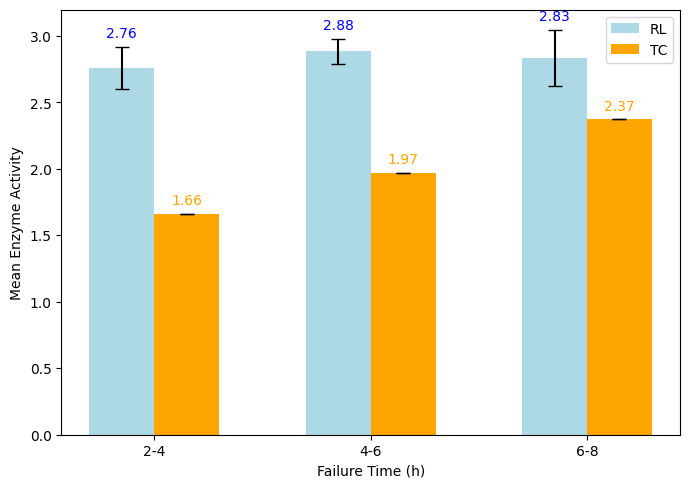

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Example enzyme activity data for both methods
RL_data = {
    '2-4': [np.float64(2.6104989568148285), np.float64(2.4581777803346543), np.float64(2.7980243223272883), np.float64(2.595349517992513), np.float64(2.8067790908703087), np.float64(3.017074985239486), np.float64(2.8903491012856284), np.float64(2.719516148481048), np.float64(2.8019343061382433), np.float64(2.903476915036655)]
,
    '4-6': [np.float64(2.9179298970053957), np.float64(2.9234892333497524), np.float64(2.7397272058056967), np.float64(2.778180908510377), np.float64(2.8519046512426645), np.float64(3.053929945915819), np.float64(2.855430372600662), np.float64(2.8085005031497983), np.float64(3.0299604820118042), np.float64(2.862194026338624)],
    '6-8': [np.float64(2.779023285537937), np.float64(2.590626617959323), np.float64(2.9450347414850597), np.float64(3.210721948745054), np.float64(3.0423606190684027), np.float64(3.00703949106987), np.float64(2.510297648515026), np.float64(2.723672021498586), np.float64(2.881440620709776), np.float64(2.6354813979680745)]

}

Traditional_data = {
    '2-4': [1.6620409778916145] * 10,
    '4-6': [1.9710138498866228] * 10,
    '6-8': [2.371213430468931] * 10
}

# Categories
categories = ['2-4', '4-6', '6-8']

# Calculate means and standard deviations for each category
means_rl = [np.mean(RL_data[cat]) for cat in categories]
std_rl = [np.std(RL_data[cat]) for cat in categories]

means_trad = [np.mean(Traditional_data[cat]) for cat in categories]
std_trad = [np.std(Traditional_data[cat]) for cat in categories]

# Bar width and x positions
bar_width = 0.30
x = np.arange(len(categories))

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Plot bars with error bars
bars_rl = ax.bar(x - bar_width/2, means_rl, bar_width, yerr=std_rl, label='RL', color='lightblue', capsize=5)
bars_trad = ax.bar(x + bar_width/2, means_trad, bar_width, yerr=std_trad, label='TC', color='orange', capsize=5)

# Add labels and title
ax.set_xlabel('Failure Time (h)')
ax.set_ylabel('Mean Enzyme Activity')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Add mean values on top of the bars
for i in range(len(categories)):
    ax.text(x[i] - bar_width/2, means_rl[i] + std_rl[i] + 0.05, f'{means_rl[i]:.2f}', 
            ha='center', va='bottom', fontsize=10, color='blue')
    ax.text(x[i] + bar_width/2, means_trad[i] + std_trad[i] + 0.05, f'{means_trad[i]:.2f}', 
            ha='center', va='bottom', fontsize=10, color='orange')

# Display the plot
plt.tight_layout()
plt.show()


# cell production vs enzyme production 

# Model Not trained for different MuE

In [3]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG


# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_rl_simulation(mux, mue):

    experiment_name = "sac_cn10cb100_df"
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    #best_model_path = os.path.join(best_model_folder, "best_model.zip")
    best_model_path = os.path.join(best_model_folder, f"{experiment_name}.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)

    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    # Initial conditions
    X0 = config.X0 # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 


    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = mue    # U/CDW g
    mu_max = mux   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

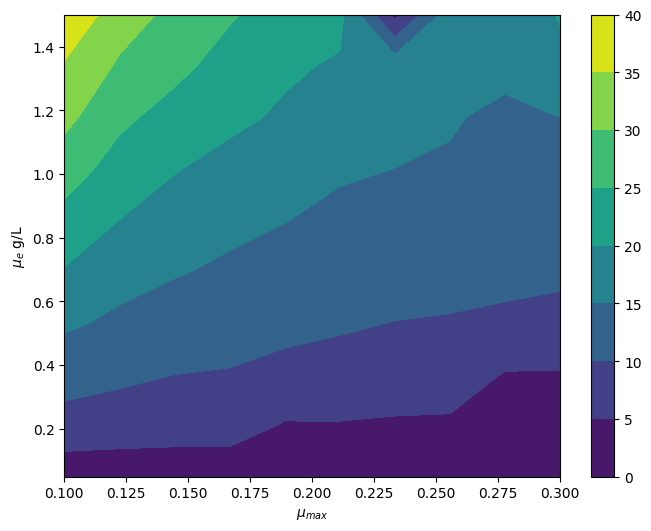

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Define the input data
mue_conc = np.linspace(0.05, 1.5, 10)  # X-axis: Initial Cell Concentrations
muX_concs = np.linspace(0.1, 0.3, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(muX_concs, mue_conc)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_rl_simulation(
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create the contour plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
contour = ax.contourf(X, Y, Z, cmap="viridis")  # Change colormap if desired
plt.colorbar(contour, ax=ax)  # Add a colorbar for reference

# Add plot labels and title
ax.set_ylabel(r'$\mu_e$ g/L')
ax.set_xlabel(r'$\mu_{max}$')

plt.show() 

# Retrained model 

In [6]:
# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_rl_simulation(mux, mue):

    experiment_name = "sac_cn10cb100_df"
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    #best_model_path = os.path.join(best_model_folder, "best_model.zip")
    best_model_path = os.path.join(best_model_folder, f"{experiment_name}.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)

    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    # Initial conditions
    X0 = config.X0 # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 


    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = mue    # U/CDW g
    mu_max = mux   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Define the input data
mue_conc = np.linspace(0.05, 1.5, 10)  # X-axis: Initial Cell Concentrations
muX_concs = np.linspace(0.1, 0.3, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(muX_concs, mue_conc)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_rl_simulation(
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create the contour plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
contour = ax.contourf(X, Y, Z, cmap="viridis")  # Change colormap if desired
plt.colorbar(contour, ax=ax)  # Add a colorbar for reference

# Add plot labels and title
ax.set_ylabel(r'$\mu_e$ g/L')
ax.set_xlabel(r'$\mu_{max}$')

plt.show() 

# Substrate to cell ratio VS MuX

In [ ]:
# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_rl_simulation_scr_mue(mux, opt_scr):

    experiment_name = "sac_cn10cb100_df"
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    #best_model_path = os.path.join(best_model_folder, "best_model.zip")
    best_model_path = os.path.join(best_model_folder, f"{experiment_name}.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)

    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    # Initial conditions
    X0 = config.X0 # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 


    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = mux   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

In [14]:
def scale_to_0_100(numbers):
    min_val = min(numbers)
    max_val = max(numbers)
    return [(x - min_val) / (max_val - min_val) * 100 for x in numbers]

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data
file_path = 'scr_mue_episode_counts.csv'  # Path to your file
data = pd.read_csv(file_path)
data.max()

SCR                 0.006
MUE_OPT             0.140
EPISODE_COUNT    1682.000
dtype: float64

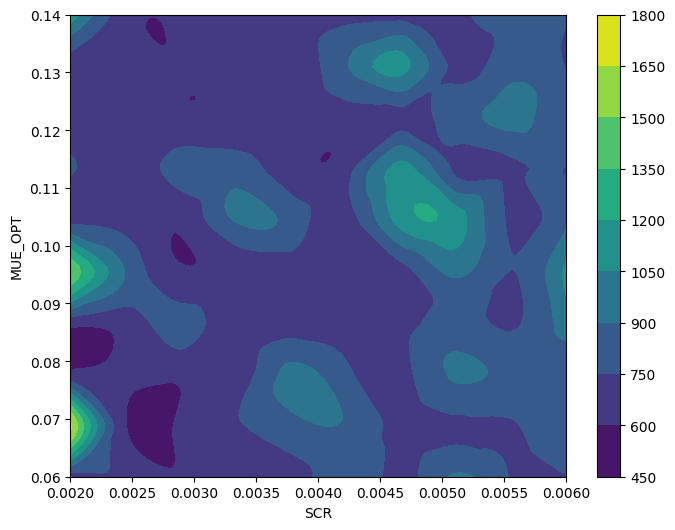

In [2]:
# Create a grid of values to be used for contour plot
x = data['SCR'].values
y = data['MUE_OPT'].values
z = data['EPISODE_COUNT'].values

# Create grid for the contour plot
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
X, Y = np.meshgrid(xi, yi)

# Interpolate the Z values on the grid
from scipy.interpolate import griddata
Z = griddata((x, y), z, (X, Y), method='cubic')

# Plot the contour plot
plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, Z, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('SCR')
plt.ylabel('MUE_OPT')
plt.show()

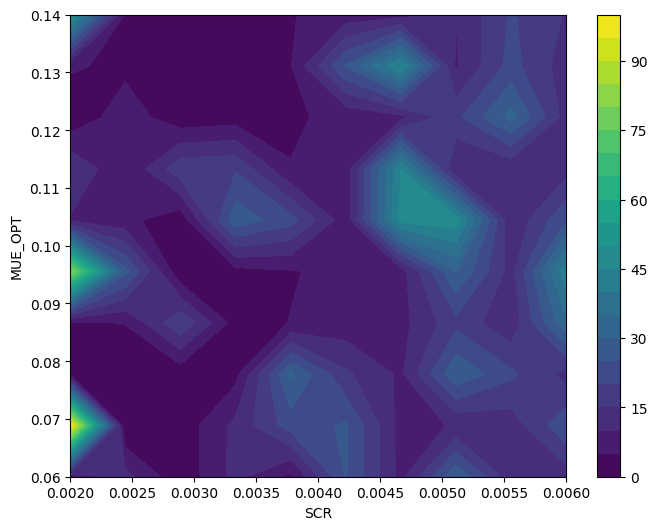

In [3]:
# Creating DataFrame
df = pd.DataFrame(data)

# Normalize EPISODE_COUNT to the range [0, 100]
min_episode, max_episode = df['EPISODE_COUNT'].min(), df['EPISODE_COUNT'].max()
df['EPISODE_COUNT_SCALED'] = 100 * (df['EPISODE_COUNT'] - min_episode) / (max_episode - min_episode)

# Pivot for contour plot
pivot_data = df.pivot(index="MUE_OPT", columns="SCR", values="EPISODE_COUNT_SCALED")

# Generate contour plot
X, Y = np.meshgrid(pivot_data.columns, pivot_data.index)
Z = pivot_data.values

plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar(contour)
plt.xlabel("SCR")
plt.ylabel("MUE_OPT")
plt.show()

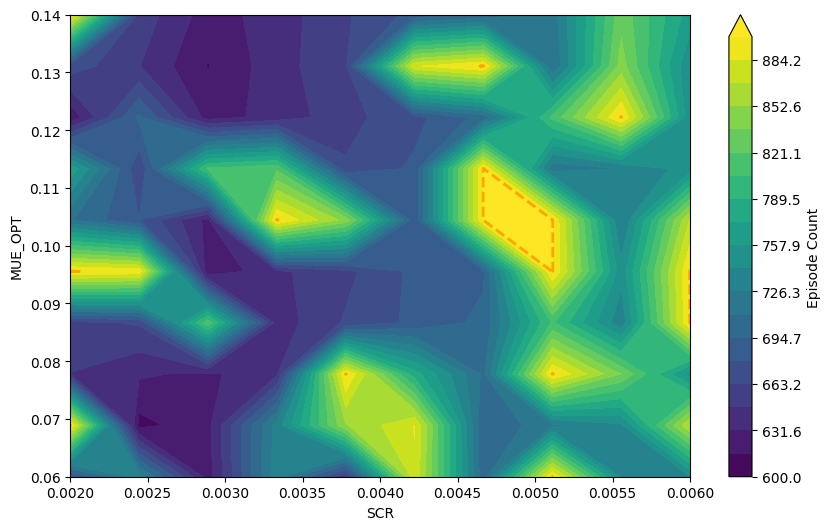

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Z-axis limits for the plot
z_min, z_max = 600, 900
high_value_marker = z_max + 1  # Value for high contrast

# Cap the EPISODE_COUNT values for visualization
data['EPISODE_COUNT_CAPPED'] = data['EPISODE_COUNT'].clip(lower=z_min, upper=high_value_marker)

# Pivot the data for contour plotting
pivot_data_capped = data.pivot(index="MUE_OPT", columns="SCR", values="EPISODE_COUNT_CAPPED")

# Create meshgrid for contour plotting
X, Y = np.meshgrid(pivot_data_capped.columns, pivot_data_capped.index)
Z_capped = pivot_data_capped.values

# Generate the contour plot
plt.figure(figsize=(10, 6))
contour = plt.contourf(X, Y, Z_capped, levels=np.linspace(z_min, z_max, 20), cmap="viridis", extend='max')
plt.colorbar(contour, label="Episode Count")

# Add a contour line for high values
plt.contour(X, Y, Z_capped, levels=[high_value_marker - 1], colors='orange', linewidths=2, linestyles='--')

# Label and title the plot
plt.xlabel("SCR")
plt.ylabel("MUE_OPT")
plt.show()
